# Innovation Results: Three-Class Classification, Ensemble, Calibration & Hierarchical

This notebook presents the results of the innovations added on top of the binary classification baseline:

1. **Three-class classification**: distinguishing NORMAL, BACTERIAL PNEUMONIA, and VIRAL PNEUMONIA
2. **Ensemble**: averaging probabilities from all ResNet18 + DenseNet121 checkpoints
3. **Calibration analysis**: ECE, reliability diagrams, and optimal decision thresholds
4. **Grad-CAM visualisations**: explainability for three-class predictions
5. **Hierarchical two-stage approach**: NORMAL-vs-PNEUMONIA followed by a dedicated BACTERIA-vs-VIRUS classifier (Kermany et al.), compared head-to-head with the flat 3-way softmax

All models were trained with seeds 0, 1, 2 for reproducibility. Results shown are mean ± std across seeds.

> **Methodological note: leakage-free evaluation.** The Kermany dataset contains several X-rays per patient, and its `val/` folder holds only 16 images (no VIRUS). We therefore carve a **patient-aware stratified validation split** (whole patients held out, ~12% per class), add **inverse-frequency class weights**, and select the best checkpoint by **macro-F1**. This fixes a data leak that previously inflated the scores: the numbers below are lower than an image-level split would report, but they are *honest* and reproducible.

In [48]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd

METRICS_DIR = Path("../results/metrics")
FIGURES_DIR = Path("../results/figures")
GRADCAM_DIR = Path("../results/gradcam")

MODELS = ["resnet18", "densenet121"]
SEEDS = [0, 1, 2]
CLASS_NAMES = ["NORMAL", "BACTERIA", "VIRUS"]
THREE_CLASS_METRICS = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "auroc"]

def load_json(path):
    with open(path) as f:
        return json.load(f)

---
## 1. Three-Class Classification Results

ResNet18 and DenseNet121 were fine-tuned for 3-class classification using a two-phase strategy:
- **Phase 1 (head-only):** only the classification head is trained, backbone frozen
- **Phase 2 (fine-tune):** full model unfrozen with a lower learning rate

Labels are derived automatically from the Kermany dataset filenames (`_bacteria_` / `_virus_`), so no extra annotation was required.

In [49]:
rows = []
for model in MODELS:
    for seed in SEEDS:
        path = METRICS_DIR / f"{model}_3class_seed{seed}.json"
        if not path.exists():
            continue
        data = load_json(path)
        row = {"Model": model, "Seed": seed}
        for m in THREE_CLASS_METRICS:
            row[m] = data.get(m)
        for cls in CLASS_NAMES:
            row[f"F1_{cls}"] = data.get("f1_per_class", {}).get(cls)
        rows.append(row)

# Ensemble
ens_path = METRICS_DIR / "ensemble_resnet18_densenet121_3class.json"
if ens_path.exists():
    data = load_json(ens_path)
    row = {"Model": "ensemble", "Seed": "-"}
    for m in THREE_CLASS_METRICS:
        row[m] = data.get(m)
    for cls in CLASS_NAMES:
        row[f"F1_{cls}"] = data.get("f1_per_class", {}).get(cls)
    rows.append(row)

df = pd.DataFrame(rows)
df

,Model,Seed,accuracy,precision_macro,recall_macro,f1_macro,auroc,F1_NORMAL,F1_BACTERIA,F1_VIRUS
0,resnet18,0,0.850962,0.845826,0.851908,0.841631,0.961528,0.855792,0.911704,0.757396
1,resnet18,1,0.674679,0.773687,0.698665,0.645864,0.924620,0.460526,0.899384,0.577681
2,resnet18,2,0.782051,0.796383,0.780251,0.766064,0.944999,0.744681,0.877127,0.676385
3,densenet121,0,0.831731,0.835082,0.832782,0.820276,0.957127,0.817043,0.909091,0.734694
4,densenet121,1,0.788462,0.800984,0.786090,0.773490,0.937533,0.769634,0.884170,0.666667
5,densenet121,2,0.775641,0.788903,0.768711,0.757217,0.936503,0.753316,0.880907,0.637427
6,ensemble,-,0.822115,0.830478,0.823952,0.808004,0.959592,0.782383,0.923679,0.717949


In [50]:
# Summary: mean ± std per model
seed_df = df[df["Seed"] != "-"].copy()
seed_df[THREE_CLASS_METRICS] = seed_df[THREE_CLASS_METRICS].astype(float)

summary_rows = []
for model in MODELS:
    sub = seed_df[seed_df["Model"] == model]
    row = {"Model": model}
    for m in THREE_CLASS_METRICS:
        mean = sub[m].mean()
        std = sub[m].std()
        row[m] = f"{mean:.4f} ± {std:.4f}"
    for cls in CLASS_NAMES:
        col = f"F1_{cls}"
        mean = sub[col].astype(float).mean()
        std = sub[col].astype(float).std()
        row[col] = f"{mean:.4f} ± {std:.4f}"
    summary_rows.append(row)

# Ensemble row (no std)
ens_row_df = df[df["Model"] == "ensemble"]
if not ens_row_df.empty:
    row = {"Model": "ensemble"}
    for m in THREE_CLASS_METRICS:
        row[m] = f"{float(ens_row_df[m].iloc[0]):.4f}"
    for cls in CLASS_NAMES:
        col = f"F1_{cls}"
        row[col] = f"{float(ens_row_df[col].iloc[0]):.4f}"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("Model")
print("Three-Class Results Summary")
summary_df

Three-Class Results Summary


,accuracy,precision_macro,recall_macro,f1_macro,auroc,F1_NORMAL,F1_BACTERIA,F1_VIRUS
Model,,,,,,,,
resnet18,0.7692 ± 0.0888,0.8053 ± 0.0369,0.7769 ± 0.0767,0.7512 ± 0.0987,0.9437 ± 0.0185,0.6870 ± 0.2038,0.8961 ± 0.0175,0.6705 ± 0.0900
densenet121,0.7986 ± 0.0294,0.8083 ± 0.0239,0.7959 ± 0.0331,0.7837 ± 0.0327,0.9437 ± 0.0116,0.7800 ± 0.0331,0.8914 ± 0.0154,0.6796 ± 0.0499
ensemble,0.8221,0.8305,0.8240,0.8080,0.9596,0.7824,0.9237,0.7179


### 1.1 Confusion Matrices

Confusion matrices for each model/seed and the ensemble. Rows = actual class, columns = predicted class.

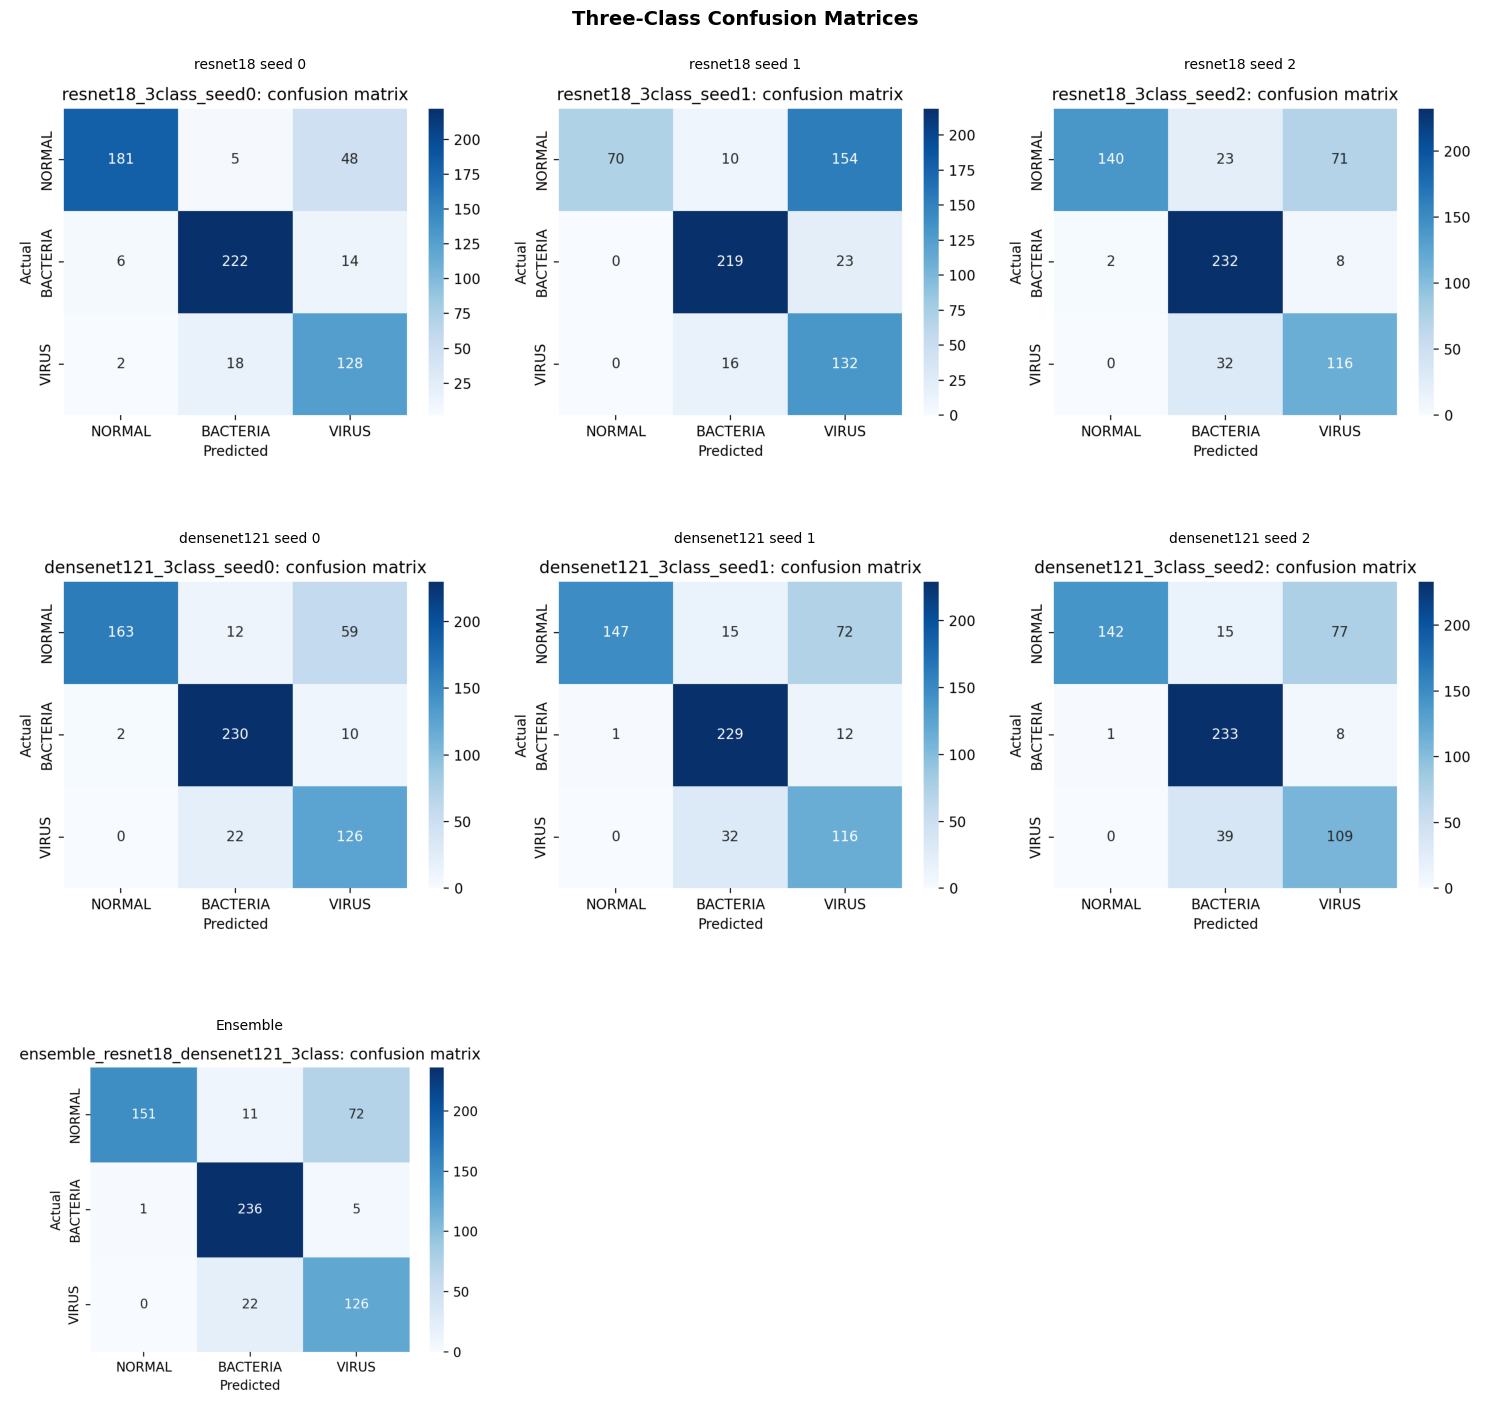

In [51]:
images_to_show = []
for model in MODELS:
    for seed in SEEDS:
        images_to_show.append((f"{model} seed {seed}", FIGURES_DIR / f"{model}_3class_seed{seed}_confusion_matrix.png"))
images_to_show.append(("Ensemble", FIGURES_DIR / "ensemble_resnet18_densenet121_3class_confusion_matrix.png"))

n = len(images_to_show)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
all_axes = np.array(axes).flatten()

for i, (title, path) in enumerate(images_to_show):
    ax = all_axes[i]
    if path.exists():
        ax.imshow(mpimg.imread(path))
        ax.set_title(title, fontsize=10)
    else:
        ax.text(0.5, 0.5, "Not found", ha="center", va="center")
    ax.axis("off")

for ax in all_axes[n:]:
    ax.set_visible(False)

plt.suptitle("Three-Class Confusion Matrices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 1.2 Training Curves

Two-phase training: head-only followed by full fine-tune. The y-axis shows F1 macro (used instead of accuracy for multi-class balance).

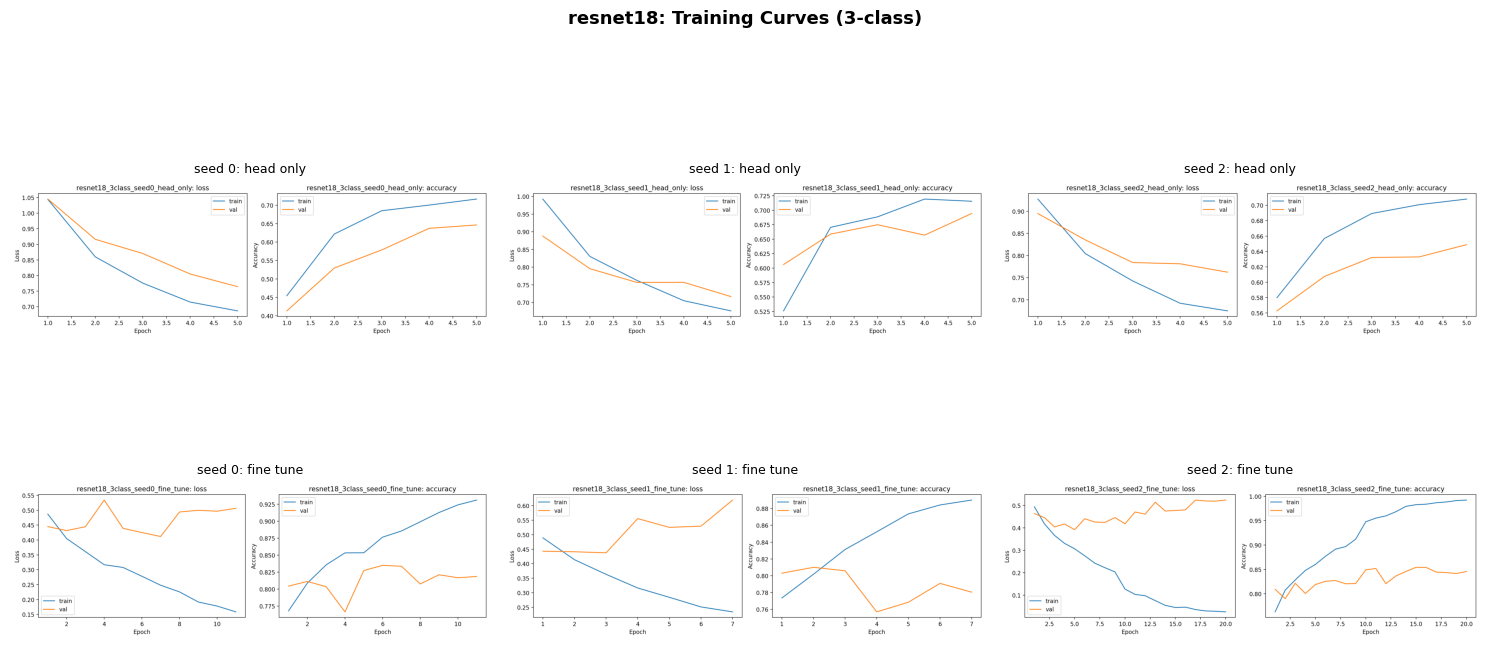

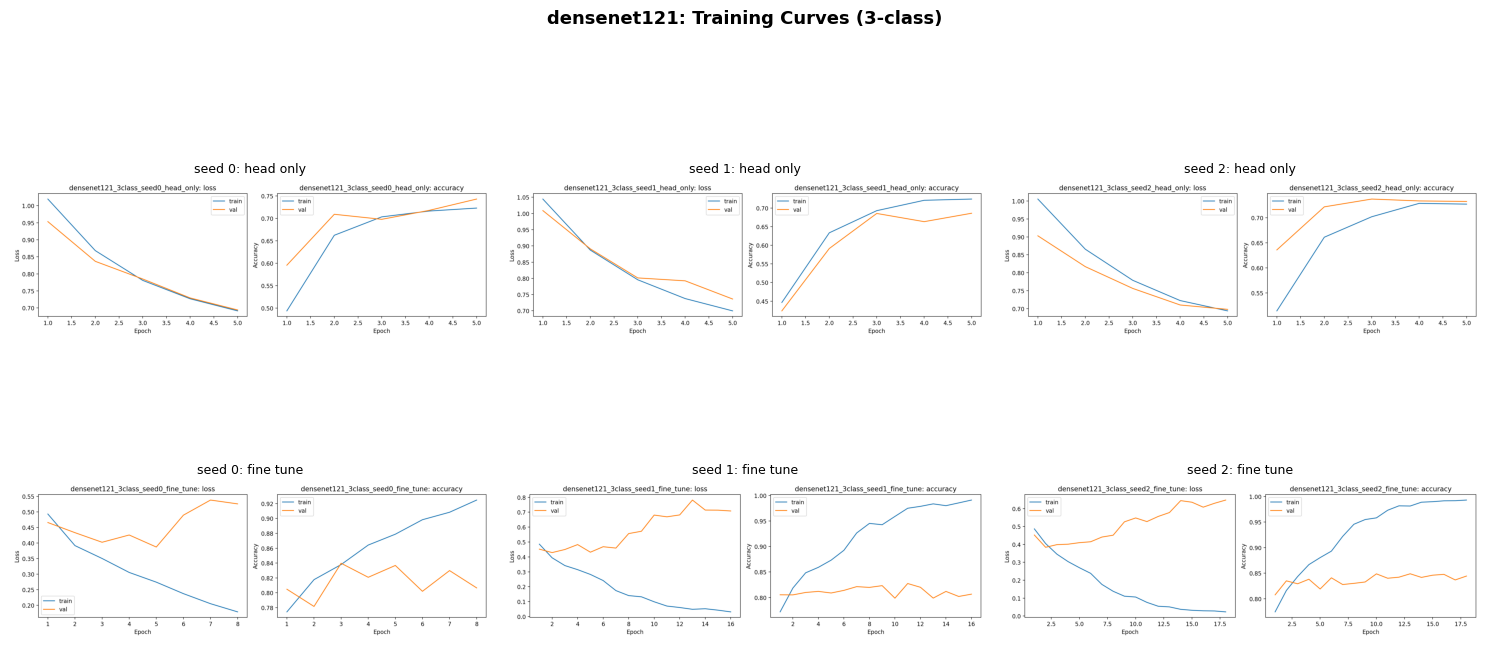

In [52]:
for model in MODELS:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f"{model}: Training Curves (3-class)", fontsize=13, fontweight="bold")
    for col, seed in enumerate(SEEDS):
        for row, phase in enumerate(["head_only", "fine_tune"]):
            path = FIGURES_DIR / f"{model}_3class_seed{seed}_{phase}_training_curves.png"
            ax = axes[row][col]
            if path.exists():
                ax.imshow(mpimg.imread(path))
                ax.set_title(f"seed {seed}: {phase.replace('_', ' ')}", fontsize=9)
            else:
                ax.text(0.5, 0.5, "Not found", ha="center", va="center")
            ax.axis("off")
    plt.tight_layout()
    plt.show()

### 1.3 Metric Comparison

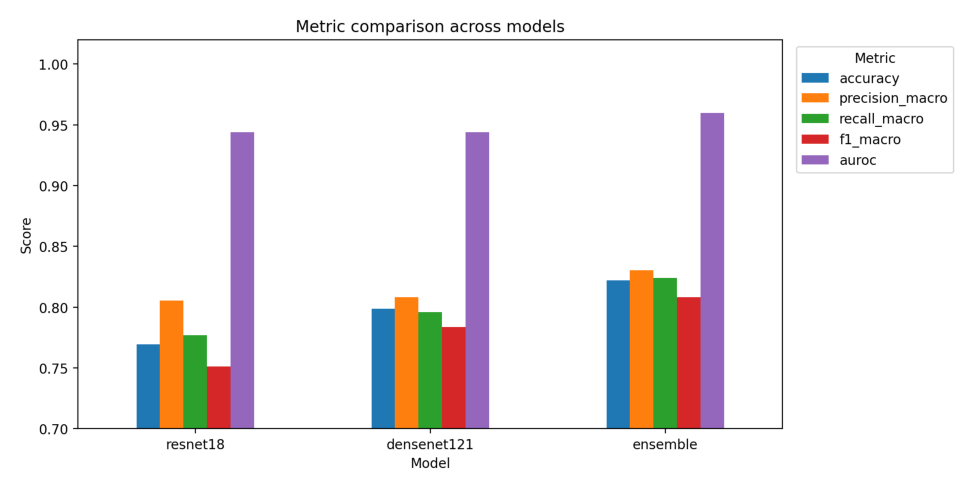

In [53]:
path = FIGURES_DIR / "metric_comparison_3class.png"
if path.exists():
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.imshow(mpimg.imread(path))
    ax.axis("off")
    plt.tight_layout()
    plt.show()

---
## 2. Ensemble

The ensemble averages the softmax probabilities of all 6 checkpoints (ResNet18 × 3 seeds + DenseNet121 × 3 seeds). This reduces variance across seeds and typically improves robustness.

Both binary and three-class ensembles were computed.

In [54]:
# Binary ensemble
ens_bin = load_json(METRICS_DIR / "ensemble_resnet18_densenet121.json")
# Three-class ensemble
ens_3cls = load_json(METRICS_DIR / "ensemble_resnet18_densenet121_3class.json")

print("Binary Ensemble")
print(f"  Accuracy   : {ens_bin['accuracy']:.4f}")
print(f"  F1         : {ens_bin['f1']:.4f}")
print(f"  AUROC      : {ens_bin['auroc']:.4f}")
print(f"  Recall     : {ens_bin['recall']:.4f}")
print(f"  Specificity: {ens_bin['specificity']:.4f}")

print("\nThree-Class Ensemble")
print(f"  Accuracy   : {ens_3cls['accuracy']:.4f}")
print(f"  F1 macro   : {ens_3cls['f1_macro']:.4f}")
print(f"  AUROC      : {ens_3cls['auroc']:.4f}")
print(f"  Members    : {ens_3cls['num_members']} checkpoints")
print()
print("Per-class F1 (3-class ensemble):")
for cls, val in ens_3cls["f1_per_class"].items():
    print(f"  {cls:<11}: {val:.4f}")

Binary Ensemble
  Accuracy   : 0.8558
  F1         : 0.8963
  AUROC      : 0.9630
  Recall     : 0.9974
  Specificity: 0.6197

Three-Class Ensemble
  Accuracy   : 0.8221
  F1 macro   : 0.8080
  AUROC      : 0.9596
  Members    : 6 checkpoints

Per-class F1 (3-class ensemble):
  NORMAL     : 0.7824
  BACTERIA   : 0.9237
  VIRUS      : 0.7179


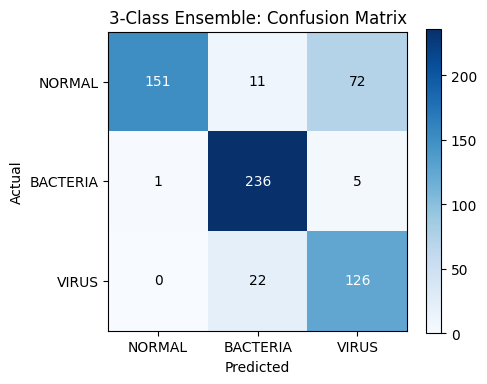

In [55]:
# Ensemble confusion matrix (inline, from JSON)
cm = np.array(ens_3cls["confusion_matrix"])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(CLASS_NAMES)
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("3-Class Ensemble: Confusion Matrix")
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

---
## 3. Calibration Analysis

A well-calibrated model outputs probabilities that reflect true likelihoods. If it predicts 80% confidence, it should be correct ~80% of the time.

**Expected Calibration Error (ECE)** measures the average gap between confidence and accuracy across bins. Lower is better.

Two clinical threshold scenarios are computed for binary models:
- **Screening threshold**: highest threshold achieving ≥99% recall (minimise false negatives)
- **F1 threshold**: threshold maximising F1 (balanced precision/recall)

In [56]:
cal = load_json(METRICS_DIR / "calibration_results.json")

cal_rows = []
for r in cal:
    ece = f"{r['ece_mean']:.4f}"
    if r.get("ece_std") is not None:
        ece += f" ± {r['ece_std']:.4f}"
    thr_screen = f"{r['threshold_screening_mean']:.4f}" if r.get("threshold_screening_mean") is not None else "n/a (multiclass)"
    thr_f1 = f"{r['threshold_f1_mean']:.4f}" if r.get("threshold_f1_mean") is not None else "n/a (multiclass)"
    cal_rows.append({"Model": r["model"], "ECE": ece, "Threshold (screening)": thr_screen, "Threshold (F1)": thr_f1})

pd.DataFrame(cal_rows).set_index("Model")

,ECE,Threshold (screening),Threshold (F1)
Model,,,
custom_cnn,0.1076 ± 0.0509,0.2450,0.5960
resnet18,0.1602 ± 0.0157,0.5926,0.9812
densenet121,0.1532 ± 0.0153,0.8595,0.9949
ensemble_resnet18_densenet121,0.1564,0.7506,0.9860
resnet18_3class,0.1260 ± 0.0739,n/a (multiclass),n/a (multiclass)
densenet121_3class,0.1510 ± 0.0890,n/a (multiclass),n/a (multiclass)
ensemble_resnet18_densenet121_3class,0.0485,n/a (multiclass),n/a (multiclass)


### 3.1 Reliability Diagrams

A reliability diagram visualises **calibration**: it groups predictions into bins by their confidence (x-axis) and plots, for each bin, the fraction that were actually correct (y-axis).

**How to read it:**
- The **dashed diagonal** is perfect calibration: *confidence = accuracy* (a bin of "70%-confident" predictions is right 70% of the time).
- The **model curve** below the diagonal means **over-confidence** (it claims more certainty than it earns); above the diagonal means **under-confidence**.
- The **vertical gap** between the curve and the diagonal, averaged over bins and weighted by how many predictions fall in each, *is* the Expected Calibration Error (ECE) reported in §3.

**Why this matters clinically.** Accuracy alone is not enough for a screening aid: the *probability* has to be trustworthy. If the model says "90% pneumonia", a clinician should be able to treat that as a genuine 90%, e.g. to triage or to defer borderline cases for review. A poorly calibrated but accurate model can still mislead by being confidently wrong. Calibration also underpins the decision thresholds in §3 (a screening threshold for ≥99% recall only means something if the probabilities are meaningful).

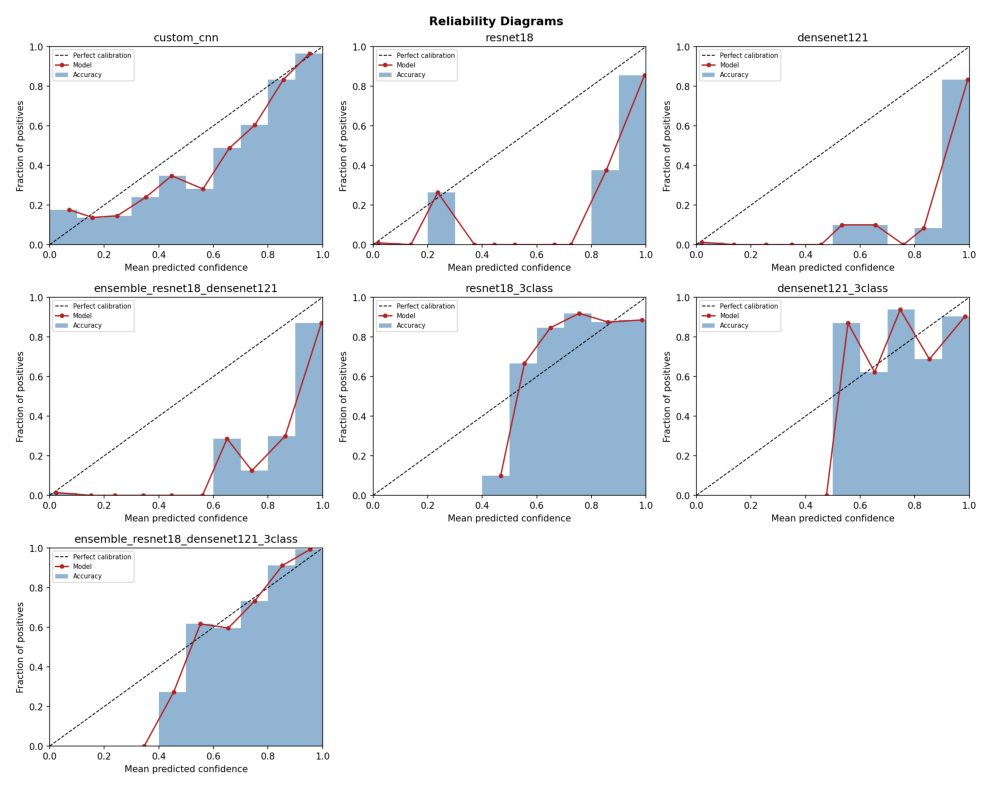

In [57]:
path = FIGURES_DIR / "reliability_diagrams.png"
if path.exists():
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.imshow(mpimg.imread(path))
    ax.axis("off")
    plt.tight_layout()
    plt.show()

**Reading the diagrams:**
- Most models are mildly **overconfident**: predictions cluster near 0 or 1, with few intermediate confidence scores, so the reliability curve tends to sit below the diagonal at high confidence.
- The **3-class ensemble is the best-calibrated model** (ECE ≈ 0.05): averaging the six checkpoints smooths out individual over-confidence, lowering ECE well below the single 3-class models (≈ 0.13–0.15) and the binary models (≈ 0.15).
- For the multi-class models, calibration is computed on the **max class probability** (a coarser proxy than a full multi-class reliability analysis), so these ECE values should be read as indicative rather than exact.

---
## 4. Grad-CAM Visualisations (Three-Class)

Grad-CAM highlights the image regions that most influenced the model's decision, shown as a grid with one row per model (**DenseNet121** and **ResNet18**) and one column per outcome category.

- **correct_X**: the model correctly classified class X, heat concentrated in diagnostically relevant regions
- **wrong_X_as_Y**: the model misclassified class X as Y, useful to understand failure modes

Note: categories are discovered from disk, so a model only shows the outcomes it actually produced. The absence of a `correct VIRUS` column reflects how rarely viral pneumonia is classified correctly, consistent with its low per-class F1.

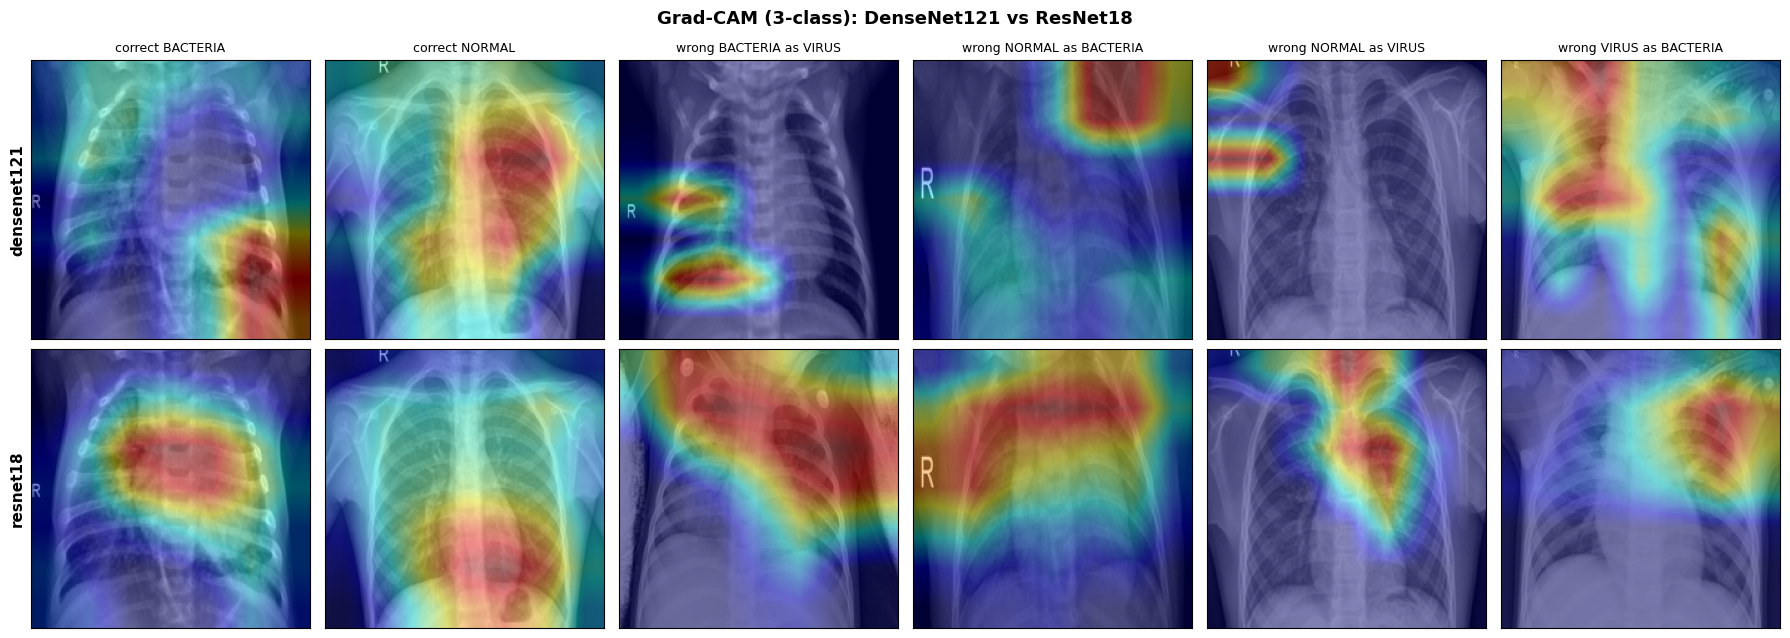

In [58]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from pathlib import Path

GRADCAM_DIR = Path("../results/gradcam")  # also defined in Setup; repeated so this cell is self-contained

# Three-class Grad-CAM grid: one row per model (DenseNet121, ResNet18),
# one column per outcome category. Categories are discovered from disk and
# shared across both models so the columns line up
def cat_of(path, model):
    # strip "<model>_3class_" prefix, then drop the trailing image filename
    stem = path.stem.replace(f"{model}_3class_", "")
    parts = stem.split("_")
    keep = []
    for p in parts:
        if p[0].isdigit() or p.startswith("IM") or p.startswith("person"):
            break
        keep.append(p)
    return "_".join(keep)

GRAD_MODELS = ["densenet121", "resnet18"]
by_model = {
    m: {cat_of(p, m): p for p in sorted(GRADCAM_DIR.glob(f"{m}_3class_*.png"))}
    for m in GRAD_MODELS
}

# Ordered union of categories (correct first, then wrong)
all_cats = sorted({c for d in by_model.values() for c in d},
                  key=lambda c: (not c.startswith("correct"), c))

n_rows, n_cols = len(GRAD_MODELS), max(len(all_cats), 1)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3.3 * n_rows))
axes = np.atleast_2d(axes)

for r, m in enumerate(GRAD_MODELS):
    for c, cat in enumerate(all_cats):
        ax = axes[r][c]
        path = by_model[m].get(cat)
        if path is not None:
            ax.imshow(mpimg.imread(path))
        else:
            ax.text(0.5, 0.5, "(no example)", ha="center", va="center", fontsize=8)
        if r == 0:
            ax.set_title(cat.replace("_", " "), fontsize=9)
        if c == 0:
            ax.set_ylabel(m, fontsize=11, fontweight="bold")
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("Grad-CAM (3-class): DenseNet121 vs ResNet18", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.1 Observations

The three-class Grad-CAM tells a richer story than the binary case, because the *errors themselves* are diagnostic of why the viral class is hard. We read each outcome by **what region drives the decision** and **whether that region is clinically the right evidence**.

**correct BACTERIA**: Both models place a sharp, focal hot-spot over a single lung region with dense opacification. This matches the textbook bacterial pattern (focal lobar consolidation), so the evidence *is* the pathology, the easiest and most clinically grounded class for both backbones, and the reason BACTERIA F1 (~0.92) is the highest of the three.

**correct NORMAL**: Activation is diffuse, with no strong focal peak: the model correctly finds nothing specific to flag. As in the binary task, the *absence* of localised lung activation is itself the right signal for a normal scan.

**wrong NORMAL → BACTERIA / NORMAL → VIRUS**: This is the **dominant error mode** (≈72/234 NORMAL images for the ensemble). The heat lands on normal vascular markings, the cardiac silhouette, or diaphragmatic shadows, which the model over-reads as infiltrate. NORMAL→VIRUS specifically dominates because faint, spread-out normal markings *look like* the diffuse interstitial viral pattern, which is exactly why NORMAL recall is the weakest of the three classes.

**wrong BACTERIA → VIRUS**: Instead of staying focal, the heat spreads bilaterally across both lungs. A partly diffuse or multifocal bacterial case is therefore read as the interstitial viral pattern, a clinically understandable confusion, since real bacterial and viral pneumonias do overlap radiologically.

**wrong VIRUS → BACTERIA**: The diffuse viral pattern has no single region to anchor on; when the model *does* find a focal-looking area it over-commits to BACTERIA. This is the mirror image of the previous error and explains why VIRUS is rarely classified correctly: its defining feature (diffuseness) is precisely what Grad-CAM struggles to localise.

**DenseNet121 vs ResNet18.** As in the binary task (notebook 01, §11), **DenseNet121's heatmaps are more anatomically focused on the lung fields**, whereas ResNet18's are more often diffuse or centred on non-parenchymal structures (mediastinum, image borders). DenseNet is therefore the more interpretable backbone, which together with its marginally higher 3-class metrics is why it is the primary model and the Stage-B classifier in the hierarchical experiment.

---
## 5. Hierarchical Two-Stage Approach

Inspired by Kermany et al., who never trained a flat 3-way classifier but instead used **two separate binary classifiers**, we test a hierarchical pipeline and compare it directly with the flat softmax:

- **Stage A**: NORMAL vs PNEUMONIA: reuses the existing **binary** DenseNet121 checkpoints (no retraining).
- **Stage B**: BACTERIA vs VIRUS: a dedicated classifier trained **only on pneumonia images**.
- **Inference**: if Stage A predicts NORMAL → `NORMAL`; otherwise Stage B decides `BACTERIA`/`VIRUS`.

Both stages use the same patient-aware split and class weights as the flat model, so the comparison is fair. The hypothesis (from the paper) was that a dedicated bacteria-vs-virus head would beat one shared softmax head on the hard viral class.

In [59]:
# Flat DenseNet121 vs Hierarchical (DenseNet121), mean ± std over seeds
def collect(prefix):
    rows = []
    for seed in SEEDS:
        p = METRICS_DIR / f"{prefix}_seed{seed}.json"
        if not p.exists():
            continue
        d = load_json(p)
        row = {m: d.get(m) for m in THREE_CLASS_METRICS}
        for cls in CLASS_NAMES:
            row[f"F1_{cls}"] = d.get("f1_per_class", {}).get(cls)
        rows.append(row)
    return pd.DataFrame(rows)

cols = THREE_CLASS_METRICS + [f"F1_{c}" for c in CLASS_NAMES]
comp_rows = []
for label, prefix in [("DenseNet121 (flat)", "densenet121_3class"),
                      ("DenseNet121 (hierarchical)", "densenet121_hierarchical")]:
    sub = collect(prefix)
    if sub.empty:
        continue
    row = {"Approach": label}
    for c in cols:
        row[c] = f"{sub[c].astype(float).mean():.4f} ± {sub[c].astype(float).std():.4f}"
    comp_rows.append(row)

comp_df = pd.DataFrame(comp_rows).set_index("Approach")
print("Flat vs Hierarchical (DenseNet121): mean ± std over seeds")
comp_df

Flat vs Hierarchical (DenseNet121): mean ± std over seeds


,accuracy,precision_macro,recall_macro,f1_macro,auroc,F1_NORMAL,F1_BACTERIA,F1_VIRUS
Approach,,,,,,,,
DenseNet121 (flat),0.7986 ± 0.0294,0.8083 ± 0.0239,0.7959 ± 0.0331,0.7837 ± 0.0327,0.9437 ± 0.0116,0.7800 ± 0.0331,0.8914 ± 0.0154,0.6796 ± 0.0499
DenseNet121 (hierarchical),0.7895 ± 0.0190,0.8082 ± 0.0098,0.7938 ± 0.0164,0.7740 ± 0.0210,0.9442 ± 0.0022,0.7315 ± 0.0430,0.9017 ± 0.0034,0.6888 ± 0.0254


Flat softmax : NORMAL->VIRUS = 208  (summed over 3 seeds)
Hierarchical : NORMAL->VIRUS = 241  (summed over 3 seeds)


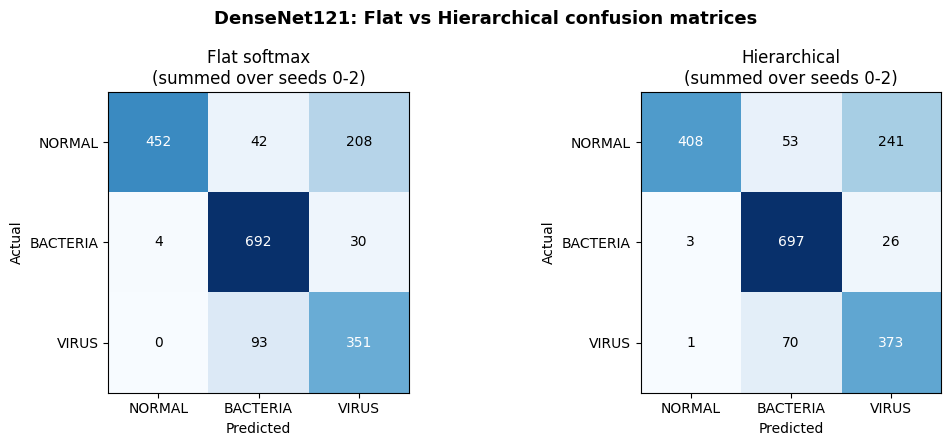

Saved figure to: ..\results\figures\densenet121_flat_vs_hierarchical_confusion.png


In [60]:
# Confusion matrices summed over seeds: flat vs hierarchical
# Highlights whether the hierarchical split changes the NORMAL->VIRUS error mode
def summed_cm(prefix):
    total = np.zeros((3, 3), dtype=int)
    for seed in SEEDS:
        p = METRICS_DIR / f"{prefix}_seed{seed}.json"
        if p.exists():
            total += np.array(load_json(p)["confusion_matrix"], dtype=int)
    return total

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (title, prefix) in zip(axes, [("Flat softmax", "densenet121_3class"),
                                       ("Hierarchical", "densenet121_hierarchical")]):
    cm = summed_cm(prefix)
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(CLASS_NAMES); ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(f"{title}\n(summed over seeds 0-2)")
    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    # Annotate the dominant NORMAL->VIRUS error
    print(f"{title:13s}: NORMAL->VIRUS = {cm[0, 2]}  (summed over 3 seeds)")

plt.suptitle("DenseNet121: Flat vs Hierarchical confusion matrices", fontsize=13, fontweight="bold")
plt.tight_layout()

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
out_path = FIGURES_DIR / "densenet121_flat_vs_hierarchical_confusion.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure to: {out_path}")

**Interpretation: the hierarchical approach did *not* beat the flat softmax.**

This is a **negative but informative result**:

- Macro-F1 is essentially tied (hierarchical ≈ 0.774 vs flat ≈ 0.784), and AUROC is identical (≈ 0.944). The hierarchical pipeline is marginally *worse*, not better.
- The dominant **NORMAL→VIRUS** error is **not** reduced by the two-stage structure: if anything it is slightly higher in some seeds.
- **Why**: the viral/bacterial boundary is an *intrinsic* difficulty of pediatric chest X-rays (viral pneumonia's diffuse interstitial pattern overlaps with both normal lungs and early bacterial infiltrates), not an artefact of using one shared head. Splitting the decision into two stages does not add discriminative signal that the images do not contain.
- A subtle disadvantage of the cascade: errors in Stage A (NORMAL vs PNEUMONIA) propagate to Stage B and cannot be recovered, whereas the flat softmax weighs all three classes jointly.

**Takeaway for the report:** we replicated the paper's two-stage philosophy and found it does not transfer to a *single* 3-class decision on this dataset. The flat softmax (and especially the ensemble) remains the better choice. This strengthens, rather than weakens, the conclusion that VIRUS is the genuine bottleneck.

---
## 6. Key Takeaways

| Finding | Detail |
|---|---|
| Evaluation rigour | Patient-aware split removes a data leak; reported numbers are honest (slightly lower than an image-level split) |
| Best 3-class model | **Ensemble** (ResNet18 + DenseNet121): macro-F1 ≈ 0.808, AUROC ≈ 0.960 |
| Best single model | DenseNet121 (flat): macro-F1 ≈ 0.784, AUROC ≈ 0.944 |
| Hierarchical vs flat | Hierarchical does **not** beat the flat softmax (macro-F1 0.774 vs 0.784) → VIRUS is an intrinsic bottleneck |
| Hardest class | VIRUS: F1 ≈ 0.72 vs ≈ 0.92 for BACTERIA |
| Dominant error | NORMAL→VIRUS (≈ 72/234 NORMAL images for the ensemble); the model rarely calls a sick lung normal |
| Calibration | 3-class ECE ≈ 0.13–0.15 for single models, and only ≈ 0.05 for the ensemble (averaging improves calibration) |
| Grad-CAM | BACTERIA activations are focal and clinically plausible; VIRUS is diffuse and rarely localised, which is why it is hardest |

**Conclusion.** The headline result is honest and consistent across every lens: the three-class task is fundamentally limited by **viral pneumonia**, whose diffuse interstitial pattern overlaps with both normal lungs and early bacterial infiltrates. This shows up everywhere: the lowest per-class F1 (VIRUS ≈ 0.72), the dominant NORMAL→VIRUS confusion, and the fact that no correctly-classified VIRUS example even appears in the Grad-CAM grid. We attacked it from three angles: **inverse-frequency class weights**, an **ensemble**, and a **hierarchical two-stage** design à la Kermany et al., and none closed the gap, which is strong evidence that it is an *intrinsic property of the data* rather than a modelling artefact. The **ensemble is the best overall 3-class predictor** (macro-F1 ≈ 0.81, AUROC ≈ 0.96, and the best-calibrated, ECE ≈ 0.05); **DenseNet121** is the preferred single model for its sharper, more interpretable Grad-CAM. Future work could target the viral class directly: VIRUS-weighted or generative augmentation, temperature scaling for calibration, or semi-supervised learning on unlabelled scans.

---
## 7. Push Innovation Checkpoints to Hugging Face

The trained weights (`.pt`) are **git-ignored** (~1.5 GB total), so we publish them to the **Hugging Face Hub** for reuse / reproducibility without retraining. This notebook uploads the **three-class** and **hierarchical (Stage B)** models; the binary models are uploaded from notebook 01, to the same repo. Files are organised under `checkpoints/three_class/` and `checkpoints/hierarchical/`.

Install and authenticate once:
```bash
pip install huggingface_hub
huggingface-cli login
```

In [61]:
from huggingface_hub import HfApi, create_repo

HF_REPO_ID = "luanacarolina/pneumonia-chest-xray-classifier"
CHECKPOINTS_DIR = Path("../results/checkpoints")

api = HfApi()
create_repo(HF_REPO_ID, exist_ok=True)

# Best checkpoint per innovation model (one representative seed each)
checkpoints_to_upload = {
    # Three-class task (NORMAL / BACTERIA / VIRUS)
    "three_class/resnet18.pt":    "resnet18_3class_seed0.pt",     # best 3-class F1-macro
    "three_class/densenet121.pt": "densenet121_3class_seed0.pt",  # primary 3-class model
    # Hierarchical Stage B (BACTERIA vs VIRUS), pneumonia images only
    "hierarchical/densenet121_bacteria_virus.pt": "densenet121_bactvirus_seed0.pt",
}

for repo_path, filename in checkpoints_to_upload.items():
    local_path = CHECKPOINTS_DIR / filename
    if not local_path.exists():
        print(f"SKIP {filename} -> not found locally")
        continue
    api.upload_file(
        path_or_fileobj=str(local_path),
        path_in_repo=f"checkpoints/{repo_path}",
        repo_id=HF_REPO_ID,
        repo_type="model",
    )
    print(f"Uploaded: {filename} -> {HF_REPO_ID}/checkpoints/{repo_path}")

Processing Files (1 / 1): 100%|██████████|  134MB /  134MB,   ???B/s  
New Data Upload: |          |  0.00B /  0.00B,   ???B/s  
No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded: resnet18_3class_seed0.pt -> luanacarolina/pneumonia-chest-xray-classifier/checkpoints/three_class/resnet18.pt


Processing Files (1 / 1): 100%|██████████| 84.4MB / 84.4MB,   ???B/s  
New Data Upload: |          |  0.00B /  0.00B,   ???B/s  
No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded: densenet121_3class_seed0.pt -> luanacarolina/pneumonia-chest-xray-classifier/checkpoints/three_class/densenet121.pt


Processing Files (1 / 1): 100%|██████████| 84.4MB / 84.4MB,   ???B/s  
New Data Upload: |          |  0.00B /  0.00B,   ???B/s  
No files have been modified since last commit. Skipping to prevent empty commit.


Uploaded: densenet121_bactvirus_seed0.pt -> luanacarolina/pneumonia-chest-xray-classifier/checkpoints/hierarchical/densenet121_bacteria_virus.pt


---
## 8. Summary & Conclusions

**What we did.** On top of the binary baseline (notebook 01), we extended the pipeline to the harder clinical question, telling **bacterial** from **viral** pneumonia, and studied it from several angles: a flat 3-way softmax (ResNet18, DenseNet121, 3 seeds each), a 6-checkpoint **ensemble**, a **hierarchical two-stage** design (NORMAL-vs-PNEUMONIA → BACTERIA-vs-VIRUS) inspired by Kermany et al., **calibration** analysis, and **Grad-CAM** explanations.

**Methodological contribution.** The most important change is not a model but the **evaluation**: a *patient-aware* stratified validation split that removes the data leak caused by multiple X-rays per patient (and by the tiny 16-image official `val/`). The reported numbers are lower than an image-level split would give, but they are **honest and reproducible** (and that rigour is itself a result).

**Main results.**
- **Ensemble is the best 3-class model**: macro-F1 ≈ 0.808, AUROC ≈ 0.960, and best-calibrated (ECE ≈ 0.05). **DenseNet121** is the preferred single model (macro-F1 ≈ 0.784) for its sharper, more interpretable Grad-CAM.
- **BACTERIA is easy** (F1 ≈ 0.92, focal consolidation); **VIRUS is the bottleneck** (F1 ≈ 0.72, diffuse pattern), driving the dominant NORMAL→VIRUS confusion.
- **The hierarchical approach did not beat the flat softmax**: a clean *negative result* showing the viral/bacterial boundary is intrinsic to the data, not a modelling artefact.

**Limitations.**
- Viral pneumonia remains hard for both models *and* for radiologists; class weighting, ensembling and the two-stage design did not close the gap.
- 3-class calibration is reported on the max-class probability (a coarse proxy); a full multi-class reliability analysis would be more precise.
- Single-institution, pediatric dataset: generalisation to other scanners/populations is untested.

**Next steps.** Target the viral class directly (VIRUS-weighted or generative augmentation, semi-supervised learning on unlabelled scans), apply temperature scaling for calibration, and validate on an external cohort. The trained checkpoints are released on the Hugging Face Hub (§7) for reuse without retraining.